# 1. Import and Hardware setup

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import time
import random

!pip install wandb -q
import wandb

In [32]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Path to your SAVED model from the previous notebook
    PRETRAINED_PATH = '/content/drive/MyDrive/DL/pre_trained_ViT_CIFAR100.pth'
    DATA_PATH = './data' # use local for much better speed
    print("✅ Connected to Google Drive")
except ImportError:
    print("❌ Not running on Colab, using local path")
    PRETRAINED_PATH = "./pre_trained_ViT_CIFAR100.pth" 
    DATA_PATH = "./data"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

# Log into W&B
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Connected to Google Drive
✅ Using device: cuda


False

# 2. Define the ViT Architecture
This has to be the exact same class definitions as utilized in the pre-training notebook. Any change here will cause weight loading errors.

In [33]:
class EmbeddedPatches(nn.Module):
    def __init__(self, img_size, in_channels, embed_dim, patch_size, batch_size):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, patch_size, patch_size)
        N = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_token = nn.Parameter(torch.randn(1, N+1, embed_dim))

    def forward(self, x):
        B = x.size(0)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.pos_token
        return x

class MLP(nn.Module):
    def __init__(self, in_features, out_features, drop_rate):
        super().__init__()
        self.layer1 = nn.Linear(in_features, out_features)
        self.layer2 = nn.Linear(out_features, in_features)
        self.dropout = nn.Dropout(drop_rate)

    def forward(self, x):
        x = self.layer1(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.dropout(x)
        return x

class VisionEncoder(nn.Module):
    def __init__(self, embed_dim, msa_size, mlp_dim, enc_dim, drop_rate):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, msa_size, drop_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img_size, patch_size, batch_size, in_channels, embed_dim, enc_dim, msa_size, mlp_dim, cls_nums, drop_rate):
        super().__init__()
        self.embed = EmbeddedPatches(img_size, in_channels, embed_dim, patch_size, batch_size)
        self.encoder = nn.Sequential(*[
            VisionEncoder(embed_dim, msa_size, mlp_dim, enc_dim, drop_rate)
            for _ in range(enc_dim)
        ])
        self.mlp_head = nn.Linear(embed_dim, cls_nums)

    def forward(self, x):
        x = self.embed(x)
        x = self.encoder(x)
        cls_token = x[:, 0]
        x = self.mlp_head(cls_token)
        return x

## 3. Hyperparameters & Configuration

-   Increase resolution to **64x64**. The model was trained on 32x32.

In [34]:
# Pre-training Config (MUST MATCH THE SAVED MODEL)
OLD_IMG_SIZE = 32
PATCH_SIZE = 4
IN_CHANNELS = 3
EMBED_DIM = 256
MLP_DIM = 512
ENC_NUMS = 6
MSA_NUMS = 8
OLD_CLS_NUMS = 100

# Fine-tuning Config
NEW_IMG_SIZE = 64
NEW_CLS_NUMS = 2
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-4
DROP_RATE = 0.1
SEED = 42

## 4. Data Loading (Food-101 Subset)

In [35]:
stats = ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Standard mean/std

train_transform = transforms.Compose([
    transforms.Resize((NEW_IMG_SIZE, NEW_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

test_transform = transforms.Compose([
    transforms.Resize((NEW_IMG_SIZE, NEW_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [36]:
from torch.utils.data import Subset, random_split
import copy

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

set_seed(SEED)

# 1. The Filter Function
def get_pizza_sushi_indices(dataset):
    target_indices = []
    pizza_idx = dataset.class_to_idx['pizza']
    sushi_idx = dataset.class_to_idx['sushi']
    for i, label in enumerate(dataset._labels):
        if label == pizza_idx or label == sushi_idx:
            target_indices.append(i)
    return target_indices

# 2. Load the Raw Datasets
full_train_raw = datasets.Food101(root=DATA_PATH, split='train', download=True, transform=train_transform)
full_test_raw = datasets.Food101(root=DATA_PATH, split='test', download=True, transform=test_transform)

# 3. Create the Pizza/Sushi Subsets
train_pizza_sushi = Subset(full_train_raw, get_pizza_sushi_indices(full_train_raw))
test_dataset = Subset(full_test_raw, get_pizza_sushi_indices(full_test_raw))

# 4. Split Training into Train/Val using random_split
train_size = int(0.8 * len(train_pizza_sushi))
val_size = len(train_pizza_sushi) - train_size
split_generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(train_pizza_sushi, [train_size, val_size], generator=split_generator)

# 5. Copy and set validation transform
val_subset.dataset = copy.copy(train_pizza_sushi)
val_subset.dataset.dataset = copy.copy(full_train_raw)
val_subset.dataset.dataset.transform = test_transform

print(f"✅ Training: {len(train_subset)}, Validation: {len(val_subset)}, Test: {len(test_dataset)}")

✅ Training: 1200, Validation: 300, Test: 500


In [37]:
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)

train_gen = torch.Generator().manual_seed(SEED)
eval_gen = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=train_gen
)

val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=eval_gen
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True, worker_init_fn=seed_worker, generator=eval_gen
)

## 5. Interpolation Logic (Custom ViT)

We need to adapt `embed.pos_token` from 32x32 size to 64x64 size.

In [38]:
def load_custom_vit_weights(model, weights_path, device):
    # 1. Load the saved weights
    state_dict = torch.load(weights_path, map_location=device)
    
    # 2. Get current model's pos_token shape
    new_pos_token = model.embed.pos_token.data
    # .data to get the raw underlying Tensor
    num_patches_new = new_pos_token.shape[1] - 1 
    # -1 because of one token from cls
    
    # 3. Get old pos_token from file (pre-trained model, 64 in this case)
    old_pos_token = state_dict['embed.pos_token']
    
    print(f"Interpolating: {old_pos_token.shape} -> {new_pos_token.shape}")

    if old_pos_token.shape != new_pos_token.shape:
        # Extract segments
        old_cls_token = old_pos_token[:, 0:1, :] # -> (1, 1, 256)
        old_grid_tokens = old_pos_token[:, 1:, :] # -> (1, 64, 256)
        
        # Calculate Grid Sizes
        grid_size_old = int(math.sqrt(old_grid_tokens.shape[1])) # Should be 32/4 = 8
        grid_size_new = int(math.sqrt(num_patches_new))          # Should be 64/4 = 16
        
        embed_dim = old_grid_tokens.shape[-1]
        
        # Convert the position embeddings from a 1D list into a 2D image-like grid
        old_grid_tokens = (old_grid_tokens.permute(0, 2, 1)
                    .reshape(1, embed_dim, grid_size_old, grid_size_old))
        # .premute(): swapping dimension (Batch, Seq, Feat) -> (Batch, Feat, Seq)
        # .reshape(): take the 64 patches and arrange them into their original
        # 2D square shape (1, 256, 64) --> (1, 256, 8, 8)
        
        # Interpolate
        new_grid_tokens = F.interpolate(
            old_grid_tokens, 
            size=(grid_size_new, grid_size_new), 
            mode='bicubic', 
            align_corners=False
        )
        
        # Reshape back
        new_grid_tokens = new_grid_tokens.flatten(2).transpose(1, 2)
        
        # Recombine
        new_pos_token = torch.cat((old_cls_token, new_grid_tokens), dim=1)
        state_dict['embed.pos_token'] = new_pos_token
        
    # 4. Handle Head Mismatch (100 classes -> 2 classes)
    # Depending on how you saved, it might be 'mlp_head.weight' and 'mlp_head.bias'
    # We usually just DROP the head weights and initialize new ones
    if 'mlp_head.weight' in state_dict:
        del state_dict['mlp_head.weight']
        del state_dict['mlp_head.bias']
        print("✅ Dropped old classification head weights")

    # 5. Load weights (strict=False allows missing head keys)
    model.load_state_dict(state_dict, strict=False)
    return model

In [39]:
# Initialize Model with NEW Configuration (64x64, 2 Classes)
model = ViT(NEW_IMG_SIZE, PATCH_SIZE, BATCH_SIZE, IN_CHANNELS, 
            EMBED_DIM, ENC_NUMS, MSA_NUMS, MLP_DIM, NEW_CLS_NUMS, DROP_RATE).to(device)

# Load and Interpolate weights
model = load_custom_vit_weights(model, PRETRAINED_PATH, device)
print("✅ Custom Model Loaded Successfully")

# Zero-initialize the head like in the ViT Paper
nn.init.zeros_(model.mlp_head.weight)
nn.init.zeros_(model.mlp_head.bias)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

# Use multiple GPUs if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Interpolating: torch.Size([1, 65, 256]) -> torch.Size([1, 257, 256])
✅ Dropped old classification head weights
✅ Custom Model Loaded Successfully
Total parameters: 3.24M


## 6. Fine-Tuning Loop

In [40]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0, save_path='best_checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.save_path = save_path
        self.early_stop = False
        self.counter = 0
        self.verbose = False
        self.best_loss = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print('Saving best checkpoint ...')
        state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state_dict, self.save_path)

In [41]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# creates a manager that arificially inflates the gradients during the
# math so they dont disappear into zeros, and then shrinks them back to
# normal size right before the weights are updated.
# ---> x2 faster 
scaler = torch.cuda.amp.GradScaler()
# Mixed Precision torch.cuda.amp: automatically switches to 16-bit numbers (FP16) for
# certain safe operations (Matrix Multiplications) to make training 
# much faster an use half the memory
# During the training, the Gradients often become extremly small,
# especially deep inside a ViT. With FP16, they might turn 0 (Gradient UnderFlow)
# --> The model stops learning completely!
# GradScaler prevents this:
# - Scale up: Before the backward pass, the Scaler multiplies all the losses
# by a large number --> push them out of the danger zone
# - The Backward Pass happens safely using FP16
# - Scale down: Before the optimizer updates the weights, the Scaler
# divides the gradients back down by that exact same large number.

/tmp/ipykernel_1432/1036672816.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [42]:

def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pizza_idx = full_train_raw.class_to_idx['pizza']
        y = (y != pizza_idx).long()

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out, y)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [43]:
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    pizza_idx = full_train_raw.class_to_idx['pizza']
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            y = (y != pizza_idx).long()
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [44]:
def evaluate(model, loader):
    model.eval()
    correct = 0

    pizza_idx = full_test_raw.class_to_idx['pizza']
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            y = (y != pizza_idx).long()

            out = model(x)
            correct += (out.argmax(1) == y).sum().item()

    return correct / len(loader.dataset)

In [45]:
wandb.init(
    project="Fine-Tuning-ViT-self-pretrained-model",
    config={
        "learning_rate": LR,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": NEW_IMG_SIZE,
        "architecture": "ViT",
        "patch_size": PATCH_SIZE,
        "embed_dim": EMBED_DIM,
        "enc_nums": ENC_NUMS,
        "msa_nums": MSA_NUMS,
        "mlp_dim": MLP_DIM,
        "drop_rate": DROP_RATE
    }
)

train_accuracies, val_accuracies = [], []
early_stopping = EarlyStopping(patience=3)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"{epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "lr": optimizer.param_groups[0]['lr']
    })

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early Stopping")
        break

model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))
print("Loaded best model")

test_acc = evaluate(model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

wandb.log({"final_test_acc": test_acc})
wandb.finish()

epoch,▁▂▃▃▄▅▆▆▇█
lr,▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▆▆▆▇▇██
train_loss,█▅▃▃▂▂▂▂▁▁
val_acc,▁▂▅▇▆▆▇▄█▆
val_loss,█▅▄▂▂▂▁▄▁▁
epoch,9
lr,0.0001
train_acc,0.92083
train_loss,0.20012
val_acc,0.9


/tmp/ipykernel_1432/2109907235.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


1/20: train_loss: 0.6109, val_loss: 0.4347, train_acc: 0.7642, val_acc: 0.8400
2/20: train_loss: 0.4058, val_loss: 0.3440, train_acc: 0.8200, val_acc: 0.8533
3/20: train_loss: 0.3453, val_loss: 0.3059, train_acc: 0.8425, val_acc: 0.8833
4/20: train_loss: 0.3146, val_loss: 0.2386, train_acc: 0.8742, val_acc: 0.9200
5/20: train_loss: 0.2786, val_loss: 0.2417, train_acc: 0.8858, val_acc: 0.9033
Early Stopping counter: 1 out of 3
6/20: train_loss: 0.2845, val_loss: 0.2463, train_acc: 0.8817, val_acc: 0.9000
Early Stopping counter: 2 out of 3
7/20: train_loss: 0.2479, val_loss: 0.2088, train_acc: 0.9008, val_acc: 0.9167
8/20: train_loss: 0.2373, val_loss: 0.3203, train_acc: 0.9017, val_acc: 0.8767
Early Stopping counter: 1 out of 3
9/20: train_loss: 0.2158, val_loss: 0.2100, train_acc: 0.9242, val_acc: 0.9267
Early Stopping counter: 2 out of 3
10/20: train_loss: 0.2001, val_loss: 0.2219, train_acc: 0.9208, val_acc: 0.9000
Early Stopping counter: 3 out of 3
Early Stopping
Loaded best model
F

epoch,▁▂▃▃▄▅▆▆▇█
final_test_acc,▁
lr,▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▆▆▆▇▇██
train_loss,█▅▃▃▂▂▂▂▁▁
val_acc,▁▂▅▇▆▆▇▄█▆
val_loss,█▅▄▂▂▂▁▄▁▁
epoch,9
final_test_acc,0.934
lr,0.0001
train_acc,0.92083


In [46]:
import os

model_name = 'FT_ViT_Pizza_Sushi.pth'
save_path = os.path.join(DATA_PATH, model_name)

torch.save(model.state_dict(), save_path)

print(f"✅ Model saved to: {save_path}")

✅ Model saved to: ./data/FT_ViT_Pizza_Sushi.pth


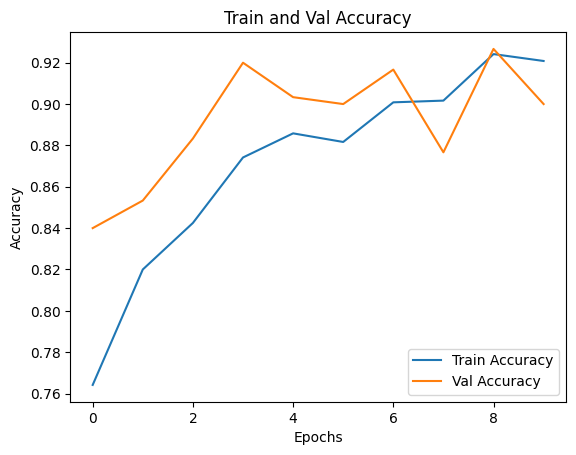

In [47]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.title("Train and Val Accuracy")
plt.show()